# Pairwise Pooling Heatmaps (Figures 5–6)

This notebook calculates directional pairwise pooling benefits for the installed-2024 portfolios of 11 balancing-authority regions. Figure 5 reports mean-load-normalized avoided energy shortfall; Figure 6 reports avoided shortfall hours. Both figures use **yearly-average** values over 2007–2023.

## Imports and pooling equations

In [1]:
from itertools import permutations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path("../data/wtk_bchrrr_nsrdb_2007_2023")
OUTPUT_DIR = Path("outputs/pairwise_pooling_heatmap")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_BUNDLE = "wtk_bchrrr_nsrdb"
PERIOD_LABEL = "2007_2023"
N_YEARS = 17

def calculate_threshold_and_delta(net_load, threshold_quantile):
    """Calculate Eq. 4 thresholds and Eq. 5 threshold-relative net load."""

    net_load_threshold_mw = net_load.quantile(threshold_quantile) # Eq. 4: estimate each BA's net-load threshold from the input time series.
    delta_mw = net_load.subtract(net_load_threshold_mw) # Eq. 5: subtract that BA-specific threshold from each aligned hour.
    return net_load_threshold_mw, delta_mw


def calculate_reference_partner_pooling(reference_delta, partner_delta) -> pd.DataFrame:
    """Apply the two-BA pooling equations to one directional reference/partner pair."""

    table = pd.DataFrame({
        "Delta_reference": pd.Series(reference_delta, dtype="float64"),
        "Delta_partner": pd.Series(partner_delta, dtype="float64"),
    })

    # Eq. 6: isolated shortfall is the positive part of each BA's delta.
    table["d_reference"] = np.maximum(table["Delta_reference"], 0)
    table["d_partner"] = np.maximum(table["Delta_partner"], 0)

    table["D_S"] = np.maximum(table["Delta_reference"] + table["Delta_partner"], 0) # Eq. 9: pooled shortfall is symmetric for the two-BA pair.
    table["PoolBenefit"] = table["d_reference"] + table["d_partner"] - table["D_S"] # Eq. 10: pooling benefit is also symmetric for the two-BA pair.
    table["Alloc_reference"] = np.minimum(table["d_reference"], table["PoolBenefit"]) # Eq. 14: allocated benefit is directional and capped by the reference BA's isolated need.

    table["PoolBenefitHours"] = ((table["d_reference"] > 0) | (table["d_partner"] > 0)).astype(float) - (table["D_S"] > 0).astype(float) # Eq. 11: hour-level indicator that pooling removed a shortfall condition.
    table["Alloc_reference_Hours"] = np.minimum((table["d_reference"] > 0).astype(float), table["PoolBenefitHours"]) # Eq. 11-derived: credit the avoided shortfall hour only when the reference BA had isolated shortfall.

    return table

## Step 1: Read and synchronize hourly data

Only the installed-2024 rows and required columns are read. All regions must have the same complete UTC index before pooling.

In [2]:
BA_CODES = ["BPAT", "CISO", "ERCO", "MISO_SUBREGION_SUM", "NYIS", "ISNE", "PJM", "SOCO", "SWPP", "TVA", "FPL"]
LABELS = {
    "BPAT": "BPA", "CISO": "CAISO", "ERCO": "ERCOT", "MISO_SUBREGION_SUM": "MISO",
    "NYIS": "NYISO", "ISNE": "ISO-NE", "PJM": "PJM", "SOCO": "SOCO",
    "SWPP": "SPP", "TVA": "TVA", "FPL": "FPL",
}

hourly_frames = []
for ba_code in BA_CODES:
    folder = "pooled_scenario_metrics" if ba_code == "MISO_SUBREGION_SUM" else "ba_scenario_metrics"
    path = DATA_ROOT / folder / f"{ba_code}_{SOURCE_BUNDLE}_{PERIOD_LABEL}_scenario_metrics.csv"
    frame = pd.read_csv(path, usecols=["time_utc", "scenario", "load_mw", "net_load_mw"])
    frame = frame.loc[frame["scenario"].eq("installed_2024")].copy()
    if frame.empty:
        raise AssertionError(f"Missing installed_2024 rows for {ba_code}.")
    frame["time_utc"] = pd.to_datetime(frame["time_utc"], utc=True)
    frame["ba_code"] = ba_code
    hourly_frames.append(frame)

hourly = pd.concat(hourly_frames, ignore_index=True)
load = hourly.pivot(index="time_utc", columns="ba_code", values="load_mw")[BA_CODES]
net_load = hourly.pivot(index="time_utc", columns="ba_code", values="net_load_mw")[BA_CODES]
assert load.index.equals(net_load.index)
assert len(load) == N_YEARS * 8760
assert load.notna().all().all() and net_load.notna().all().all()
print(f"Synchronized {len(load):,} hourly rows for {len(BA_CODES)} regions ({load.index.min()} to {load.index.max()}).")

Synchronized 148,920 hourly rows for 11 regions (2007-01-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00).


## Steps 2–3: Thresholds and ordered pairs

Each region uses its own pooled-time P95 net-load threshold. Threshold-relative net load is divided by that region's mean load before the directional allocation calculation.

In [3]:
THRESHOLD_QUANTILE = 0.95
threshold_mw, delta_mw = calculate_threshold_and_delta(net_load, THRESHOLD_QUANTILE)
mean_load_mw = load.mean()
normalized_delta = delta_mw / mean_load_mw

rows = []
for reference_ba, partner_ba in permutations(BA_CODES, 2):
    pooling = calculate_reference_partner_pooling(normalized_delta[reference_ba], normalized_delta[partner_ba])
    rows.append({
        "reference_ba": reference_ba,
        "partner_ba": partner_ba,
        "avoided_energy_shortfall_total": pooling["Alloc_reference"].sum(),
        "avoided_shortfall_hours_total": pooling["Alloc_reference_Hours"].sum(),
    })

ordered_pairs = pd.DataFrame(rows)
ordered_pairs["avoided_energy_shortfall_per_year"] = ordered_pairs["avoided_energy_shortfall_total"] / N_YEARS
ordered_pairs["avoided_shortfall_hours_per_year"] = ordered_pairs["avoided_shortfall_hours_total"] / N_YEARS
assert len(ordered_pairs) == len(BA_CODES) * (len(BA_CODES) - 1)
assert ordered_pairs.filter(like="avoided").ge(-1e-9).all().all()
ordered_pairs.to_csv(OUTPUT_DIR / "ordered_pair_metrics.csv", index=False)

energy_per_year = ordered_pairs.pivot(
    index="reference_ba", columns="partner_ba", values="avoided_energy_shortfall_per_year"
).reindex(index=BA_CODES, columns=BA_CODES)
hours_per_year = ordered_pairs.pivot(
    index="reference_ba", columns="partner_ba", values="avoided_shortfall_hours_per_year"
).reindex(index=BA_CODES, columns=BA_CODES)
display(ordered_pairs.head(8).round(3))

,reference_ba,partner_ba,avoided_energy_shortfall_total,avoided_shortfall_hours_total,avoided_energy_shortfall_per_year,avoided_shortfall_hours_per_year
0,BPAT,CISO,606.665,6281.0,35.686,369.471
1,BPAT,ERCO,623.653,6551.0,36.685,385.353
2,BPAT,MISO_SUBREGION_SUM,613.026,6320.0,36.060,371.765
3,BPAT,NYIS,658.619,6668.0,38.742,392.235
4,BPAT,ISNE,586.132,5865.0,34.478,345.000
5,BPAT,PJM,606.248,6182.0,35.662,363.647
6,BPAT,SOCO,658.829,6808.0,38.755,400.471
7,BPAT,SWPP,645.578,6719.0,37.975,395.235


## Step 4: Plot Figures 5–6

The same yearly-average matrices supply the plotted colors, annotations, and color bars; no display-only scaling is applied.

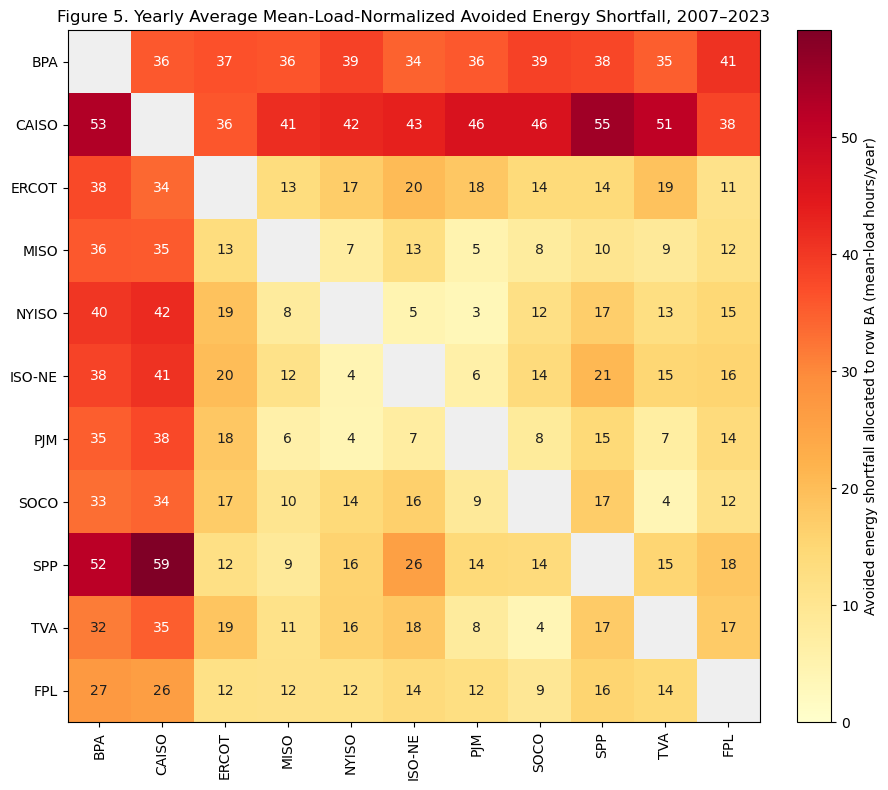

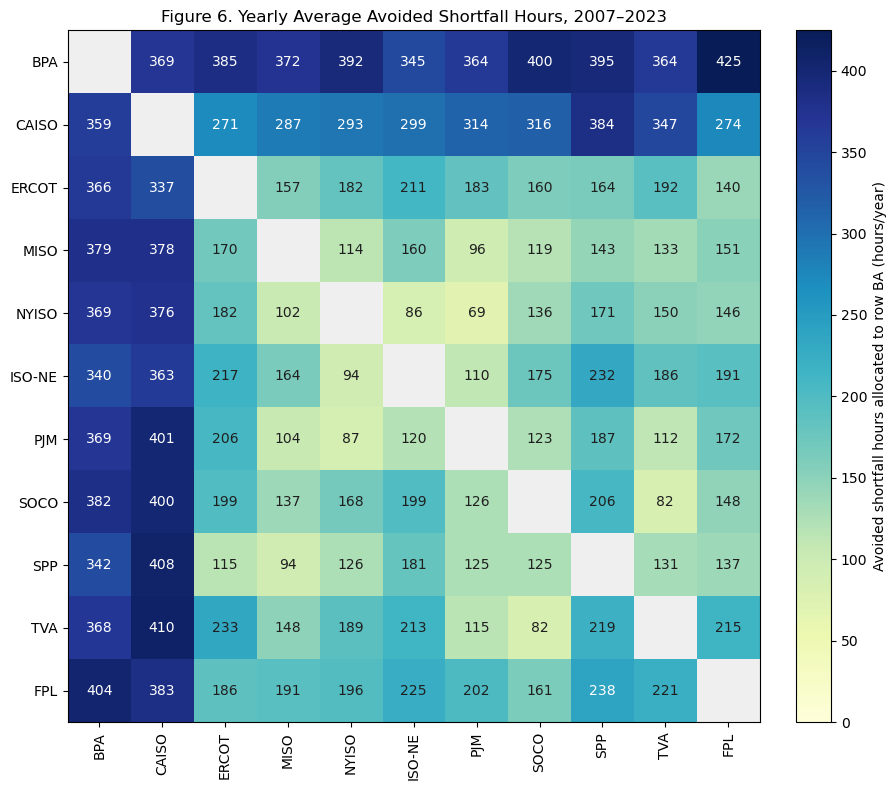

Saved outputs\pairwise_pooling_heatmap\figure_5_mean_load_normalized_avoided_energy_shortfall.png and outputs\pairwise_pooling_heatmap\figure_6_mean_load_normalized_avoided_shortfall_hours.png.


In [4]:
def plot_pairwise_heatmap(matrix, title, output_path, cmap_name, colorbar_label):
    values = matrix.to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    vmax = max(float(finite.max()), 1.0)
    labels = [LABELS.get(code, code) for code in BA_CODES]

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("#efefef")
    image = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(labels)), labels, rotation=90)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title(title)
    for row in range(len(labels)):
        for column in range(len(labels)):
            value = values[row, column]
            if np.isfinite(value):
                color = "white" if value >= 0.55 * vmax else "#1f1f1f"
                ax.text(column, row, f"{value:.0f}", ha="center", va="center", fontsize=10, color=color)
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(colorbar_label)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)


figure_5_path = OUTPUT_DIR / "figure_5_mean_load_normalized_avoided_energy_shortfall.png"
figure_6_path = OUTPUT_DIR / "figure_6_mean_load_normalized_avoided_shortfall_hours.png"
plot_pairwise_heatmap(
    energy_per_year,
    "Figure 5. Yearly Average Mean-Load-Normalized Avoided Energy Shortfall, 2007–2023",
    figure_5_path,
    "YlOrRd",
    "Avoided energy shortfall allocated to row BA (mean-load hours/year)",
)
plot_pairwise_heatmap(
    hours_per_year,
    "Figure 6. Yearly Average Avoided Shortfall Hours, 2007–2023",
    figure_6_path,
    "YlGnBu",
    "Avoided shortfall hours allocated to row BA (hours/year)",
)
print(f"Saved {figure_5_path} and {figure_6_path}.")